In [ ]:
# initialization
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy import constants
hbar = constants.physical_constants["reduced Planck constant in eV s"][0]
uB = constants.physical_constants["Bohr magneton in eV/T"][0] * 1e-3
g = constants.physical_constants["electron g factor"][0] * -1

# operators
U = Qobj([[0, 1/np.sqrt(2), -1/np.sqrt(2), 0],
           [0, 1/np.sqrt(2),  1/np.sqrt(2), 0],
           [1, 0, 0, 0],
           [0, 0, 0, 1]])
U.dims = [[2, 2], [2,2]] # qutip is pedantic

# this should be a class :p
def make_solver(j_numerator, k_s, k_d):
    # n, where n/2 is the nuclear spin
    j = j_numerator/2
    j_dim = j_numerator + 1

    # spin operator definitions
    sztot1 = tensor(U * tensor((1/2)*sigmaz(), qeye(2)) * U.dag(), qeye(j_dim))
    sztot2 = tensor(U * tensor(qeye(2), (1/2)*sigmaz()) * U.dag(), qeye(j_dim))
    sxtot1 = tensor(U * tensor((1/2)*sigmax(), qeye(2)) * U.dag(), qeye(j_dim))
    sxtot2 = tensor(U * tensor(qeye(2), (1/2)*sigmax()) * U.dag(), qeye(j_dim))
    sytot1 = tensor(U * tensor((1/2)*sigmay(), qeye(2)) * U.dag(), qeye(j_dim))
    sytot2 = tensor(U * tensor(qeye(2), (1/2)*sigmay()) * U.dag(), qeye(j_dim))

    iz = tensor(tensor(qeye(2), qeye(2)), spin_Jz(j))
    ix = tensor(tensor(qeye(2), qeye(2)), spin_Jx(j))
    iy = tensor(tensor(qeye(2), qeye(2)), spin_Jy(j))

    # defining projection operators
    singket = basis(4, 0) # 'singlet' and 'ket' ,,, get it?
    lower_proj_singlet = singket * singket.dag()
    lower_proj_singlet.dims = [[2,2], [2,2]] # qutip is pedantic
    lower_proj_triplet = (tensor(qeye(2), qeye(2)) - lower_proj_singlet)

    # raised projection operators
    proj_singlet = tensor(lower_proj_singlet, qeye(j_dim))
    proj_triplet = tensor(lower_proj_triplet, qeye(j_dim))

    # defining projection anticommutators
    def superanticommutator(proj_op, k):
        return k * (spre(proj_op) + spost(proj_op))
    singletanticom = superanticommutator(proj_singlet, k_s + k_d)
    tripletanticom = superanticommutator(proj_triplet, k_d)

    dim = 4 * j_dim

    # defining hamiltonians
    H_0 = g * uB * (sztot1 + sztot2)
    H_1 = g * uB * (ix * sxtot1 + iy * sytot1 + iz * sztot1)

    def solver(Bz):
        L = liouvillian(Bz * H_0 + H_1)/hbar + 1/2 * singletanticom + 1/2 * tripletanticom
        L_matrix = L.full()
        source = (1/dim) * np.eye(dim).flatten()
        L_matrix[-1, :] = [1 if i % (dim + 1) == 0 else 0 for i in range(dim**2)]
        source[-1] = 1.0
        rhoss = np.linalg.solve(L_matrix, source).reshape(dim, dim)
        return np.trace(proj_singlet.full() * rhoss)
    # initialization of solver function complete
    return solver
def do_solve(lower_bound, upper_bound, step, solver):
    Bzs = []
    tracesinglets = []
    a = 0
    b = np.abs(lower_bound) + np.abs(upper_bound) - step
    for Bz in np.arange(lower_bound, upper_bound, step):
        Bzs.append(Bz)
        tracesinglets.append(solver(Bz))
        print(f'Progress: {a/b*100:.2f}%', end='\r', flush=True)
        a += step
    plt.plot(Bzs, tracesinglets)
    return Bzs, tracesinglets

In [ ]:
# Stochastic Liouville Equation Solver

# modules and constants
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy import constants
from scipy.sparse.linalg import spsolve
from scipy.sparse import csr_matrix
from multiprocessing.pool import ThreadPool
hbar = constants.physical_constants["reduced Planck constant in eV s"][0]
uB = constants.physical_constants["Bohr magneton in eV/T"][0] * 1e-3
g = constants.physical_constants["electron g factor"][0] * -1

# transformation matrix for product spin basis and total spin basis
U = Qobj([[0, 1/np.sqrt(2), -1/np.sqrt(2), 0],
           [0, 1/np.sqrt(2),  1/np.sqrt(2), 0],
           [1, 0, 0, 0],
           [0, 0, 0, 1]])
U.dims = [[2, 2], [2,2]] # qutip is pedantic

# single electron spin operators in total spin basis; will be used by solver to construct
# the same for the full system
sztot1 = U * tensor((1/2)*sigmaz(), qeye(2)) * U.dag()
sztot2 = U * tensor(qeye(2), (1/2)*sigmaz()) * U.dag()
sxtot1 = U * tensor((1/2)*sigmax(), qeye(2)) * U.dag()
sxtot2 = U * tensor(qeye(2), (1/2)*sigmax()) * U.dag()
sytot1 = U * tensor((1/2)*sigmay(), qeye(2)) * U.dag()
sytot2 = U * tensor(qeye(2), (1/2)*sigmay()) * U.dag()

# defining projection operators
singket = basis(4, 0) # 'singlet' and 'ket' ,,, get it?
lower_proj_singlet = singket * singket.dag()
lower_proj_singlet.dims = [[2,2], [2,2]] # qutip is pedantic
lower_proj_triplet = (tensor(qeye(2), qeye(2)) - lower_proj_singlet)

# anticommutator superoperator for SLE
def superanticommutator(proj_op, k):
    return k * (spre(proj_op) + spost(proj_op))

# raises operators such that qutip isn't angered
def raiseop(operator, index, spin_dims):
    Is = [qeye(int(d)) for d in spin_dims]
    Is[index] = operator
    op = tensor(Is)
    return op

class Solver:
    def __init__(self, k_s, k_d, H_number, *j_numerators):

        if len(j_numerators) < 1:
            raise ValueError('Must provide at least one nuclear spin')
        if (H_number >= 2) and (len(j_numerators) < 2):
            raise ValueError('Must provide two nuclear spins for Hamiltonian 2')
        self.all_spin_numerators = np.array([1, 1] + list(j_numerators))
        self.j_numerators = np.array(j_numerators)
        self.sj = self.all_spin_numerators / 2
        self.j = self.j_numerators / 2
        self.j_dims = self.j_numerators + 1
        self.all_dims = self.all_spin_numerators + 1
        self.total_dim = np.prod(self.all_dims)

        # raising electron spin operators
        dims_e = np.concatenate([[4], self.j_dims])
        # spin operator definitions
        self.ops = {'sz1': raiseop(sztot1, 0, dims_e),
               'sz2': raiseop(sztot2, 0, dims_e),
               'sx1': raiseop(sxtot1, 0, dims_e),
               'sx2': raiseop(sxtot2, 0, dims_e),
               'sy1': raiseop(sytot1, 0, dims_e),
               'sy2': raiseop(sytot2, 0, dims_e)
               }

        # raising nuclear spin operators
        for direction, spinop in [('z', spin_Jz), ('x', spin_Jx), ('y', spin_Jy)]:
            for i, k in enumerate(self.sj[2:]):
                name = 'j' + direction + str(i+1)
                base_operator = spinop(k)
                self.ops[name] = raiseop(base_operator, i+2, self.all_dims)

        # raised projection operators
        self.proj_singlet = raiseop(lower_proj_singlet, 0, np.concatenate([[3], self.j_dims]))
        self.proj_triplet = raiseop(lower_proj_triplet, 0, np.concatenate([[3], self.j_dims]))

        # creating relevant anticommutators
        self.singletanticom = superanticommutator(self.proj_singlet, k_s + k_d)
        self.tripletanticom = superanticommutator(self.proj_triplet, k_d)

        # defining hamiltonians
        H_0 = g * uB * (self.ops['sz1'] + self.ops['sz2'])
        self.Hs = [H_0]
        for i in range(H_number):
            self.Hs.append((self.ops['jz' + str(i + 1)] * self.ops['sz' + str(i + 1)] + \
                                self.ops['jx' + str(i + 1)] * self.ops['sx' + str(i + 1)] + \
                                self.ops['jy' + str(i + 1)] * self.ops['sy' + str(i + 1)]) * g * uB)
        
        self.Hssum = np.sum(self.Hs[1:])
        
    # builds SLE, passes to scipy sparse matrix solver, solves, then gets singlet trace    
    def solver(self, Bz):
        L = liouvillian(Bz * self.Hs[0] + self.Hssum) / hbar + \
            1/2 * self.singletanticom + 1/2 * self.tripletanticom
        L_matrix = csr_matrix(L.full())
        source = (1/self.total_dim) * np.eye(self.total_dim).flatten()
        L_lil = L_matrix.tolil()
        L_lil[-1: 0] = 0
        for i in range(self.total_dim):
            L_lil[-1, i * (self.total_dim + 1)] = 1
        L_matrix = L_lil.tocsr()
        source[-1] = 1.0
        rhoss = spsolve(L_matrix, source).reshape(self.total_dim, self.total_dim)
        return np.trace(self.proj_singlet.full() * rhoss)

    # parallelized with threadpool; solves SLE for many Bz 
    def solve(self, lower_bound, upper_bound, step):
        self.Bzs = []
        self.tracesinglets = []
        self.Bzs = list(np.arange(lower_bound, upper_bound, step))

        with ThreadPool() as p:
            self.tracesinglets = p.map(self.solver, self.Bzs)

        plt.plot(self.Bzs, self.tracesinglets)

[0.5 0.5 1.5 1.5]


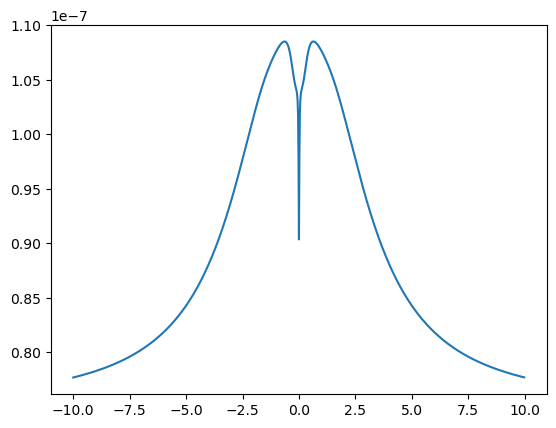

In [9]:
test = Solver(4e6, 1e6, 2, 3, 3)
test.solve(-10, 10, .02)

In [77]:
a = test.ops
a['sz1'] * a['sz2'] - a['sz2'] * a['sz1']
test.total_dim

np.int64(8)

In [26]:
g = ['a', 'b', 'c', 'd', 'e', 'f']
print(g[1:])
for i, k in enumerate(g[2:]):
    print(i, k)
spin_Jz(1.5)

['b', 'c', 'd', 'e', 'f']
0 c
1 d
2 e
3 f


Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.5  0.   0.   0. ]
 [ 0.   0.5  0.   0. ]
 [ 0.   0.  -0.5  0. ]
 [ 0.   0.   0.  -1.5]]

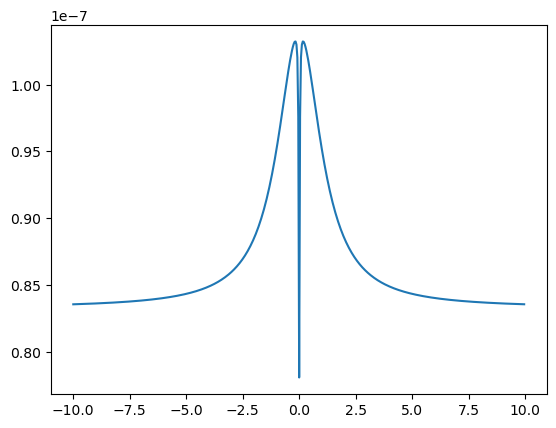

In [14]:
k_s = 4e6
k_d = 1e6
j = 1
low = -10
high = 10
step = .04
solver = make_solver(j, k_s, k_d)
spin1_2 = do_solve(low, high, step, solver)

/home/ryan/.conda/envs/harmon/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ryan/.conda/envs/harmon/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


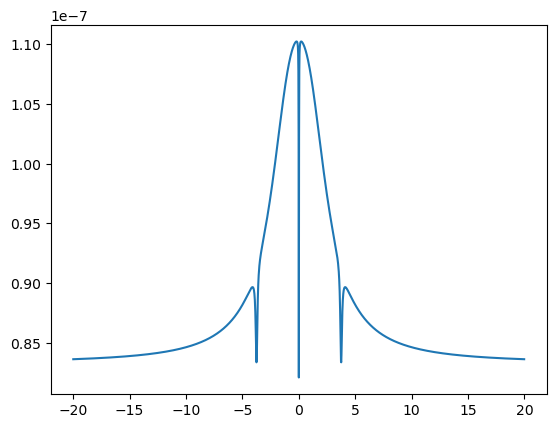

In [2]:
k_s = 4e6
k_d = 1e6
j = 3
low = -20
high = 20
step = .02
solver = make_solver(j, k_s, k_d)
spin3_2 = do_solve(low, high, step, solver)

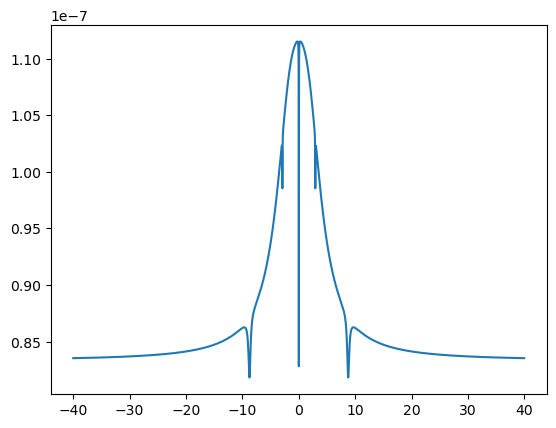

In [3]:
k_s = 4e6
k_d = 1e6
j = 5
low = -40
high = 40
step = .04
solver = make_solver(j, k_s, k_d)
spin5_2 = do_solve(low, high, step, solver)

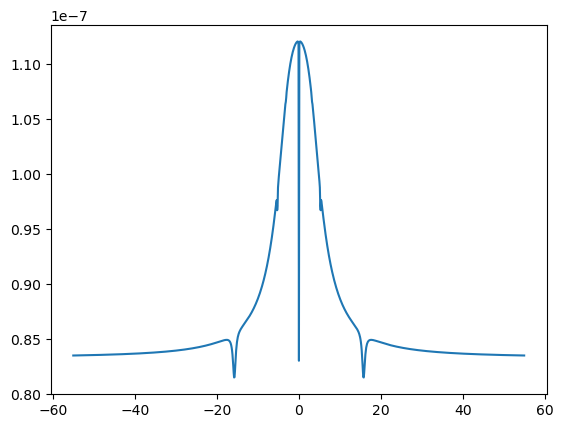

In [ ]:
k_s = 4e6
k_d = 1e6
j = 7
low = -55
high = 55
step = .1
# CUDA SWITCH POINT
# yeah i thinnk this one takes like 15 minutes on this computer :p
solver = make_solver(j, k_s, k_d)
spin7_2 = do_solve(low, high, step, solver)

In [4]:
print(g)

2.00231930436092
